Computing 2D Quenching Matrix: 100%|██████████| 100/100 [00:12<00:00,  7.92it/s]


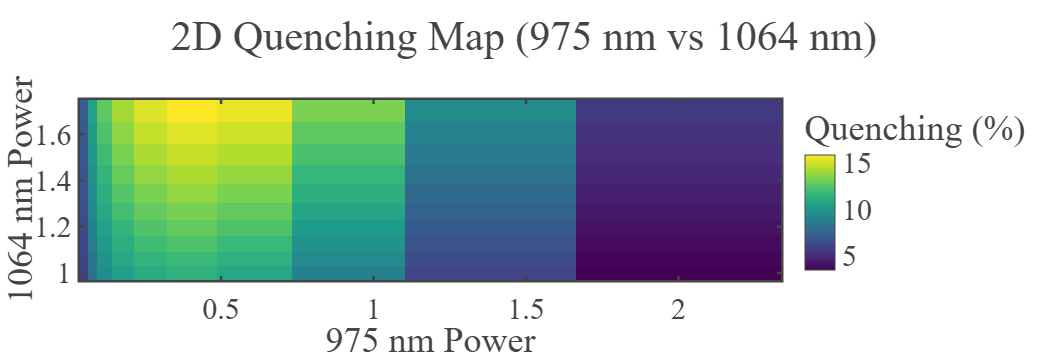

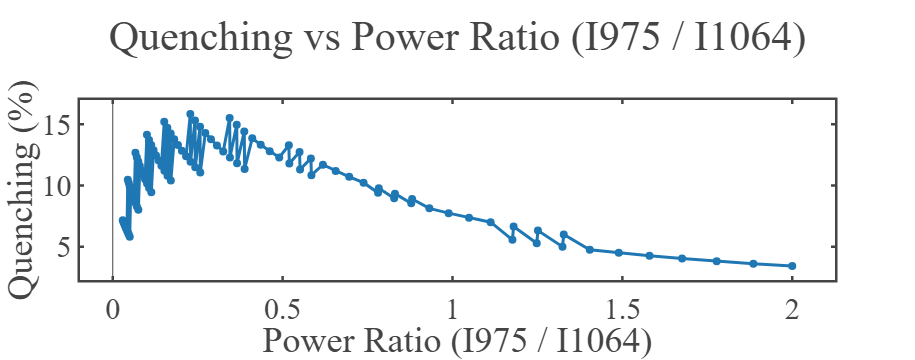

In [2]:
"""
2D Quenching map (parallelized)
- Quenching vs (975nm, 1064nm)
- Heatmap of quenching percentage
- Sorted Quenching vs ratio (I975 / I1064)
"""

import numpy as np
import plotly.graph_objects as go
from scipy.integrate import solve_ivp
from joblib import Parallel, delayed
from tqdm import tqdm
from contextlib import contextmanager


# ============================================================
# --- Figure template ---
# ============================================================
fig_template = go.layout.Template()
fig_template.layout = {
    'template': 'simple_white+presentation',
    'autosize': False,
    'width': 800,
    'height': 600,
    'xaxis': {
        'ticks': 'inside', 'mirror': 'ticks', 'linewidth': 2.5,
        'tickwidth': 2.5, 'ticklen': 4, 'showline': True, 'showgrid': False
    },
    'yaxis': {
        'ticks': 'inside', 'mirror': 'ticks', 'linewidth': 2.5,
        'tickwidth': 2.5, 'ticklen': 4, 'showline': True, 'showgrid': False
    },
    'font': {'family': 'mathjax', 'size': 30}
}


# ============================================================
# --- Joblib + tqdm helper ---
# ============================================================
@contextmanager
def tqdm_joblib(tqdm_object):
    """Context manager to integrate tqdm with joblib."""
    import joblib

    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback

    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_callback
        tqdm_object.close()


# ============================================================
# --- Time grid ---
# ============================================================
t_max = 3000.0
dt = 0.5
t_eval = np.linspace(0, t_max, int(t_max/dt) + 1)


# ============================================================
# --- Pulse parameters ---
# ============================================================
laser_on = 200.0
laser_off = 200.0
period = laser_on + laser_off
phase_shift = laser_on

def make_I1064_func(I_1064_peak):
    def I1064(t):
        phase = np.mod(t + phase_shift, period)
        return np.where(phase < laser_on, I_1064_peak, 0.0)
    return I1064


# ============================================================
# --- Lifetimes ---
# ============================================================
beta1 = 1/5.0
beta2 = 1/100.0


# ============================================================
# --- Coefficients ---
# ============================================================
k_alpha1 = 0.1
k_alpha1p = 0.1
k_alpha2 = 0.001
k_alpha2p = 0.001
k_gamma_975 = 0.001
k_gamma_1064 = 0.2


# ============================================================
# --- Main simulation function ---
# ============================================================
def run_sim(I_975, I_1064_peak):

    I1064 = make_I1064_func(I_1064_peak)

    def I975(t):
        return I_975 if np.isscalar(t) else np.full_like(t, I_975)

    def alpha1(t):  return k_alpha1 * I975(t) + k_alpha2 * I1064(t)
    def alpha1p(t): return k_alpha1p * I975(t) + k_alpha2p * I1064(t)
    def gamma975(t):  return k_gamma_975 * I975(t)
    def gamma1064(t): return k_gamma_1064 * I1064(t)

    def rate_equations(t, N):
        N0, N1, N2 = N
        a1  = alpha1(t)
        a1p = alpha1p(t)
        g1  = gamma975(t)
        g2  = gamma1064(t)
        dN0 = -a1*N0 + (beta1+g1+g2)*N1 + beta2*N2
        dN1 = a1*N0 - (a1p+beta1+g1+g2)*N1
        dN2 = a1p*N1 - beta2*N2
        return [dN0, dN1, dN2]

    sol = solve_ivp(rate_equations, [0, t_max], [1,0,0],
                    t_eval=t_eval, atol=1e-9, rtol=1e-7)

    t  = sol.t
    N2 = sol.y[2]
    emission = beta2 * N2

    steady_cut = 5 * period
    mask = t >= steady_cut
    phase = np.mod(t + phase_shift, period)

    off_mask = mask & (phase >= laser_on)
    on_mask  = mask & (phase <  laser_on)

    if off_mask.sum() == 0 or on_mask.sum() == 0:
        return np.nan

    mean_off = emission[off_mask].mean()
    mean_on  = emission[on_mask].mean()

    return (mean_off - mean_on) / mean_off * 100.0


# ============================================================
# --- Power grids ---
# ============================================================
powers_975  = np.geomspace(0.05, 2, 10)
powers_1064 = np.geomspace(1.0, 1.7, 10)

N1 = len(powers_975)
N2 = len(powers_1064)

Q = np.zeros((N2, N1))


# ============================================================
# --- Parallel 2D simulation ---
# ============================================================
tasks = [(i, j, p975, p1064)
         for j, p1064 in enumerate(powers_1064)
         for i, p975 in enumerate(powers_975)]

with tqdm_joblib(tqdm(total=len(tasks), desc="Computing 2D Quenching Matrix")):
    results = Parallel(n_jobs=-1)(
        delayed(lambda x: (x[0], x[1], run_sim(x[2], x[3])))(task)
        for task in tasks
    )

for i, j, q in results:
    Q[j, i] = q


# ============================================================
# --- PLOT 1: 2D HEATMAP ---
# ============================================================
fig_hm = go.Figure(data=go.Heatmap(
    x=powers_975,
    y=powers_1064,
    z=Q,
    colorscale="Viridis",
    colorbar_title="Quenching (%)"
))
fig_hm.update_layout(
    template=fig_template,
    title="2D Quenching Map (975 nm vs 1064 nm)",
    xaxis_title="975 nm Power",
    yaxis_title="1064 nm Power",
)
fig_hm.show()


# ============================================================
# --- PLOT 2: Quenching vs Ratio (sorted) ---
# ============================================================
ratio_list = []
quench_list = []

for j, p1064 in enumerate(powers_1064):
    for i, p975 in enumerate(powers_975):
        ratio_list.append(p975 / p1064)
        quench_list.append(Q[j, i])

# Sort by increasing ratio
ratio_sorted, quench_sorted = zip(*sorted(zip(ratio_list, quench_list)))

fig_ratio = go.Figure()
fig_ratio.add_trace(go.Scatter(
    x=ratio_sorted,
    y=quench_sorted,
    mode='markers+lines',
    marker=dict(size=8),
    line=dict(width=3)
))
fig_ratio.update_layout(
    template=fig_template,
    title="Quenching vs Power Ratio (I975 / I1064)",
    xaxis_title="Power Ratio (I975 / I1064)",
    yaxis_title="Quenching (%)",
)
fig_ratio.show()
